In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Make repo importable =====
# 假设 notebook 在: CS50-analysis/tests/Harmonic_pattern_demo.ipynb
REPO_ROOT = Path.cwd().resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)

from stock_analysis.config import SLD_WINDOW_CONFIG

REPO_ROOT = C:\Users\17866\OneDrive\桌面\Ltq\2026a\data5703\project\work\current_work\CS50-analysis


## Import the data

In [2]:
# path
data_path = REPO_ROOT / "TestData" / "stock_hourly_OHLC_long.csv"


df = pd.read_csv(data_path)
print(df.head())

                    Datetime Ticker        Open        High         Low  \
0  2024-04-24 13:30:00+00:00   AAPL  166.399994  168.300003  166.210007   
1  2024-04-24 14:30:00+00:00   AAPL  167.994995  168.279999  167.520004   
2  2024-04-24 15:30:00+00:00   AAPL  167.925003  169.274994  167.910004   
3  2024-04-24 16:30:00+00:00   AAPL  168.725006  168.850006  168.110001   
4  2024-04-24 17:30:00+00:00   AAPL  168.470001  169.289993  168.460007   

        Close  
0  167.994995  
1  167.919998  
2  168.725006  
3  168.461700  
4  168.750000  


In [3]:
df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Datetime").reset_index(drop=True)
print(df_aapl.shape)
df_aapl.head()

(3474, 6)


,Datetime,Ticker,Open,High,Low,Close
0,2024-04-24 13:30:00+00:00,AAPL,166.399994,168.300003,166.210007,167.994995
1,2024-04-24 14:30:00+00:00,AAPL,167.994995,168.279999,167.520004,167.919998
2,2024-04-24 15:30:00+00:00,AAPL,167.925003,169.274994,167.910004,168.725006
3,2024-04-24 16:30:00+00:00,AAPL,168.725006,168.850006,168.110001,168.461700
4,2024-04-24 17:30:00+00:00,AAPL,168.470001,169.289993,168.460007,168.750000


## Tools Function Initialization

Load Every Chart Pattern Detector

In [4]:
import pkgutil
import importlib
import inspect

from stock_analysis.base import BasePattern
import stock_analysis.chart_patterns as chart_pkg


def load_chart_detectors():
    detectors = []

    for _, module_name, _ in pkgutil.iter_modules(chart_pkg.__path__):
        full_module_name = f"{chart_pkg.__name__}.{module_name}"
        module = importlib.import_module(full_module_name)

        for _, obj in inspect.getmembers(module, inspect.isclass):
            if issubclass(obj, BasePattern) and obj is not BasePattern:
                if getattr(obj, "enabled", False):
                    try:
                        detectors.append(obj())
                    except Exception as e:
                        print(f"Skip detector {obj.__name__}: {e}")

    return detectors


chart_detectors = load_chart_detectors()
print(f"Loaded {len(chart_detectors)} chart detectors:")
for d in chart_detectors:
    print("-", d.__class__.__name__)

Loaded 20 chart detectors:
- AscendingChannelChartPattern
- AscendingTriangleChartPattern
- CupAndHandleChartPattern
- DescendingChannelChartPattern
- DescendingTriangleChartPattern
- DiamondBottomChartPattern
- DiamondTopChartPattern
- DoubleBottomChartPattern
- DoubleTopChartPattern
- FallingWedgeChartPattern
- FlagChartPattern
- HeadAndShouldersChartPattern
- InverseHeadAndShouldersChartPattern
- MegaphoneChartPattern
- PennantChartPattern
- RectangleChartPattern
- RisingWedgeChartPattern
- SymmetricalTriangleChartPattern
- TripleBottomChartPattern
- TripleTopChartPattern


In [5]:
def run_detector(detector, df_window: pd.DataFrame) -> dict | None:
    """
    Run one chart detector safely.
    Returns the detector result dict or None if failed.
    """
    try:
        if hasattr(detector, "_run"):
            result = detector._run(df_window)
        elif hasattr(detector, "run"):
            result = detector.run(df_window)
        else:
            return None

        if not isinstance(result, dict):
            return None

        return result

    except Exception as e:
        # first version: just skip failures
        return None

pre trend

In [6]:
from stock_analysis.trendanalysis import TrendAnalysis

trend_analyzer = TrendAnalysis()

In [7]:
def project_pretrend_analysis(df_window: pd.DataFrame) -> dict:
    trend = trend_analyzer.pre_trend_analysis(df_window)
    if trend is None:
        return {
            "label": "unknown",
            "strength": 0.0,
            "higher_high_ratio": 0.0,
            "higher_low_ratio": 0.0,
            "lower_high_ratio": 0.0,
            "lower_low_ratio": 0.0,
            "candles": len(df_window),
        }
    return trend

Formation

In [8]:
from stock_analysis.config import SLD_WINDOW_CONFIG

def is_valid_chart_signal(result: dict, min_confidence: float = 60) -> bool:
    if not result:
        return False

    if result.get("confirmed", False):
        return True

    if result.get("structure_detected", False) and result.get("confidence", 0) >= min_confidence:
        return True

    return False


def collect_chart_formations_at_t(
    df_hist: pd.DataFrame,
    detectors: list,
    recent_windows_per_pattern: int = 3,
    verbose: bool = False,
) -> list[dict]:
    formations = []

    chart_cfg = SLD_WINDOW_CONFIG["chart_patterns"]
    window_size = chart_cfg["window_size"]
    min_candles = chart_cfg["min_candles"]

    if len(df_hist) < max(window_size, min_candles):
        return formations

    for detector in detectors:
        pattern_name = detector.__class__.__name__

        for window_count in range(1, recent_windows_per_pattern + 1):
            end_idx = len(df_hist) - (window_count - 1)
            start_idx = end_idx - window_size

            if start_idx < 0:
                continue

            df_window = df_hist.iloc[start_idx:end_idx].reset_index(drop=True)

            if len(df_window) < min_candles:
                continue

            result = run_detector(detector, df_window)

            if not is_valid_chart_signal(result, min_confidence=60):
                continue

            formation = {
                "pattern": pattern_name,
                "confidence": result.get("confidence", 0),
                "window_count": window_count,
                "pre_trend": project_pretrend_analysis(df_window),
                "signal": {
                    "direction": result.get("direction"),
                    "pivots": result.get("pivots", []),
                },
                "raw_result": result,
            }

            formations.append(formation)

            if verbose:
                print(
                    f"[FOUND] {pattern_name} | "
                    f"window={window_count} | "
                    f"confidence={formation['confidence']} | "
                    f"direction={formation['signal']['direction']}"
                )

    return formations

In [9]:
CHART_PATTERN_WINDOW_SIZE = {
    "DoubleTopChartPattern": 60,
    "DoubleBottomChartPattern": 60,
    "TripleTopChartPattern": 90,
    "TripleBottomChartPattern": 90,
    "HeadAndShouldersChartPattern": 100,
    "InverseHeadAndShouldersChartPattern": 100,
    "AscendingTriangleChartPattern": 90,
    "DescendingTriangleChartPattern": 90,
    "SymmetricalTriangleChartPattern": 90,
    "AscendingChannelChartPattern": 120,
    "DescendingChannelChartPattern": 120,
    "RisingWedgeChartPattern": 100,
    "FallingWedgeChartPattern": 100,
    "RectangleChartPattern": 80,
    "MegaphoneChartPattern": 100,
    "DiamondTopChartPattern": 120,
    "DiamondBottomChartPattern": 120,
    "FlagChartPattern": 40,
    "PennantChartPattern": 40,
    "CupAndHandleChartPattern": 180,
}


def collect_chart_formations_at_t(
    df_hist: pd.DataFrame,
    detectors: list,
    recent_windows_per_pattern: int = 3,
    verbose: bool = False,
) -> list[dict]:
    formations = []

    chart_cfg = SLD_WINDOW_CONFIG["chart_patterns"]
    default_window_size = chart_cfg["window_size"]
    min_candles = chart_cfg["min_candles"]

    for detector in detectors:
        pattern_name = detector.__class__.__name__

        window_size = CHART_PATTERN_WINDOW_SIZE.get(
            pattern_name,
            default_window_size
        )

        if len(df_hist) < max(window_size, min_candles):
            continue

        for window_count in range(1, recent_windows_per_pattern + 1):
            end_idx = len(df_hist) - (window_count - 1)
            start_idx = end_idx - window_size

            if start_idx < 0:
                continue

            df_window = df_hist.iloc[start_idx:end_idx].reset_index(drop=True)

            if len(df_window) < min_candles:
                continue

            result = run_detector(detector, df_window)

            if not is_valid_chart_signal(result, min_confidence=60):
                continue

            formation = {
                "pattern": pattern_name,
                "confidence": result.get("confidence", 0),
                "window_count": window_count,
                "window_size": window_size,
                "pre_trend": project_pretrend_analysis(df_window),
                "signal": {
                    "direction": result.get("direction"),
                    "pivots": result.get("pivots", []),
                },
                "raw_result": result,
            }

            formations.append(formation)

            if verbose:
                print(
                    f"[FOUND] {pattern_name} | "
                    f"window_size={window_size} | "
                    f"window_count={window_count} | "
                    f"confidence={formation['confidence']} | "
                    f"direction={formation['signal']['direction']}"
                )

    return formations

context score

In [10]:
from stock_analysis.context_scores.chart_context_score import context_score as chart_context_score

## Backtest

In [11]:
def backtest_chart_context_score(
    df: pd.DataFrame,
    detectors: list,
    min_history: int = 120,
    future_horizon: int = 30,
    recent_windows_per_pattern: int = 3,
    return_lookback: int = 30,
) -> pd.DataFrame:
    """
    Prototype backtest for chart context score.

    At each time t:
    - use df[:t+1] as historical data
    - collect chart formations
    - compute context score
    - compare with:
        1. recent_return: past return from t-return_lookback to t
        2. future_return: future return from t to t+future_horizon
    """
    records = []

    start_t = max(min_history, return_lookback)

    for t in range(start_t, len(df) - future_horizon):
        df_hist = df.iloc[:t+1].copy()

        past_row = df.iloc[t - return_lookback]
        current_row = df.iloc[t]
        future_row = df.iloc[t + future_horizon]

        formations = collect_chart_formations_at_t(
            df_hist=df_hist,
            detectors=detectors,
            recent_windows_per_pattern=recent_windows_per_pattern,
        )

        ctx = chart_context_score(formations)

        past_close = past_row["Close"]
        current_close = current_row["Close"]
        future_close = future_row["Close"]

        recent_return = (current_close - past_close) / max(abs(past_close), 1e-9)
        future_return = (future_close - current_close) / max(abs(current_close), 1e-9)

        bias = ctx["bias"]
        score = ctx["score"]
        agreement = ctx["agreement"]

        if bias == "bullish":
            recent_correct = int(recent_return > 0)
            future_correct = int(future_return > 0)
        elif bias == "bearish":
            recent_correct = int(recent_return < 0)
            future_correct = int(future_return < 0)
        else:
            recent_correct = np.nan
            future_correct = np.nan

        records.append({
            "t": t,
            "Datetime": current_row["Datetime"],

            "score": score,
            "bias": bias,
            "agreement": agreement,
            "bull_score": ctx["bull_score"],
            "bear_score": ctx["bear_score"],
            "pattern_count": ctx["pattern_count"],

            "recent_return": recent_return,
            "future_return": future_return,

            "past_close": past_close,
            "current_close": current_close,
            "future_close": future_close,

            "recent_correct": recent_correct,
            "future_correct": future_correct,

            "formations": formations,
            "context_detail": ctx,
        })

    return pd.DataFrame(records)

In [12]:
tickers = [
    "AAPL", "MSFT", "NVDA", "TSLA", "GOOGL",
    "AMZN", "META", "JPM", "BAC", "GS"
]

In [13]:
all_results = []

for ticker in tickers:
    print(f"\nRunning chart backtest for {ticker}...")

    df_ticker = (
        df[df["Ticker"] == ticker]
        .copy()
        .sort_values("Datetime")
        .reset_index(drop=True)
    )

    if len(df_ticker) < 180:
        print(f"{ticker}: skipped, not enough data")
        continue

    try:
        result = backtest_chart_context_score(
            df=df_ticker,
            detectors=chart_detectors,
            min_history=240,
            future_horizon=65,
            recent_windows_per_pattern=10,
            return_lookback=65,
        )

        if result.empty:
            print(f"{ticker}: empty result")
            continue

        result["Ticker"] = ticker
        all_results.append(result)

        print(f"{ticker}: done, rows = {len(result)}")

    except Exception as e:
        print(f"{ticker}: failed -> {e}")

chart_backtest_all = pd.concat(all_results, ignore_index=True)

print("\nAll backtest results:")
print(chart_backtest_all.shape)
chart_backtest_all.head()


Running chart backtest for AAPL...
AAPL: done, rows = 3169

Running chart backtest for MSFT...
MSFT: done, rows = 3169

Running chart backtest for NVDA...
NVDA: done, rows = 3169

Running chart backtest for TSLA...
TSLA: done, rows = 3169

Running chart backtest for GOOGL...
GOOGL: skipped, not enough data

Running chart backtest for AMZN...
AMZN: done, rows = 3169

Running chart backtest for META...
META: skipped, not enough data

Running chart backtest for JPM...
JPM: skipped, not enough data

Running chart backtest for BAC...
BAC: skipped, not enough data

Running chart backtest for GS...
GS: skipped, not enough data

All backtest results:
(15845, 18)


,t,Datetime,score,bias,agreement,bull_score,bear_score,pattern_count,recent_return,future_return,past_close,current_close,future_close,recent_correct,future_correct,formations,context_detail,Ticker
0,240,2024-06-12 15:30:00+00:00,68.998,bullish,1.0,100.0,0.0,15,0.124866,-0.004644,191.445007,215.350006,214.350006,1.0,0.0,"[{'pattern': 'AscendingChannelChartPattern', '...","{'score': 68.998, 'pattern_score': 73.747, 'ms...",AAPL
1,241,2024-06-12 16:30:00+00:00,64.704,bullish,1.0,100.0,0.0,13,0.131641,-0.016909,191.695007,216.929993,213.261993,1.0,0.0,"[{'pattern': 'AscendingChannelChartPattern', '...","{'score': 64.704, 'pattern_score': 68.38, 'mss...",AAPL
2,242,2024-06-12 17:30:00+00:00,60.964,bullish,1.0,100.0,0.0,11,0.144830,-0.026672,191.259995,218.960205,213.119995,1.0,0.0,"[{'pattern': 'AscendingChannelChartPattern', '...","{'score': 60.964, 'pattern_score': 63.704, 'ms...",AAPL
3,243,2024-06-12 18:30:00+00:00,57.839,bullish,1.0,100.0,0.0,9,0.133546,-0.018004,192.078705,217.729996,213.809998,1.0,0.0,"[{'pattern': 'AscendingChannelChartPattern', '...","{'score': 57.839, 'pattern_score': 59.799, 'ms...",AAPL
4,244,2024-06-12 19:30:00+00:00,55.309,bullish,1.0,100.0,0.0,7,0.112651,-0.000663,191.535004,213.111694,212.970505,1.0,0.0,"[{'pattern': 'AscendingChannelChartPattern', '...","{'score': 55.309, 'pattern_score': 56.636, 'ms...",AAPL


In [14]:
corr_records = []

for ticker, group in chart_backtest_all.groupby("Ticker"):
    temp = group[["score", "recent_return", "future_return"]].dropna()

    if len(temp) < 10:
        print(f"{ticker}: skipped correlation, too few valid rows")
        continue

    recent_corr = temp["score"].corr(temp["recent_return"])
    future_corr = temp["score"].corr(temp["future_return"])

    corr_records.append({
        "Ticker": ticker,
        "Recent_Return_Corr": recent_corr,
        "Future_Return_Corr": future_corr,
        "N": len(temp)
    })

corr_df = pd.DataFrame(corr_records)

print(corr_df)

  Ticker  Recent_Return_Corr  Future_Return_Corr     N
0   AAPL            0.404923           -0.180107  3169
1   AMZN            0.431323           -0.126968  3169
2   MSFT            0.366529            0.049860  3169
3   NVDA            0.426131           -0.141811  3169
4   TSLA            0.334602            0.032876  3169


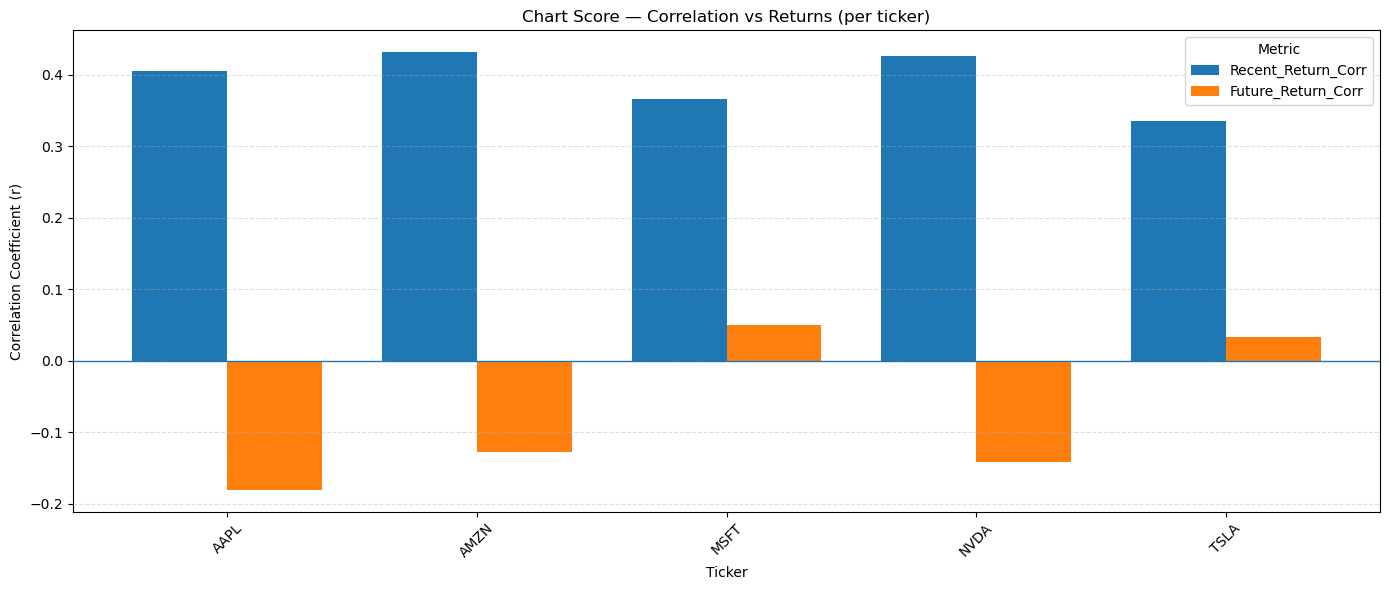

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = corr_df.copy()
plot_df = plot_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    plot_df["Recent_Return_Corr"],
    width,
    label="Recent_Return_Corr"
)

plt.bar(
    x + width / 2,
    plot_df["Future_Return_Corr"],
    width,
    label="Future_Return_Corr"
)

plt.axhline(0, linewidth=1)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("Correlation Coefficient (r)")
plt.xlabel("Ticker")
plt.title("Chart Score — Correlation vs Returns (per ticker)")
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

chart_metric_records = []

for ticker, group in chart_backtest_all.groupby("Ticker"):
    temp = group[group["bias"].isin(["bullish", "bearish"])].copy()

    if len(temp) < 10:
        print(f"{ticker}: skipped, too few directional rows")
        continue

    # Actual direction
    temp["recent_true"] = np.where(temp["recent_return"] > 0, 1, 0)
    temp["future_true"] = np.where(temp["future_return"] > 0, 1, 0)

    # Prediction direction
    temp["pred"] = np.where(temp["bias"] == "bullish", 1, 0)

    chart_metric_records.append({
        "Ticker": ticker,

        "Recent_Accuracy": accuracy_score(temp["recent_true"], temp["pred"]),
        "Future_Accuracy": accuracy_score(temp["future_true"], temp["pred"]),

        "Recent_Precision": precision_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_Precision": precision_score(temp["future_true"], temp["pred"], zero_division=0),

        "Recent_Recall": recall_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_Recall": recall_score(temp["future_true"], temp["pred"], zero_division=0),

        "Recent_F1": f1_score(temp["recent_true"], temp["pred"], zero_division=0),
        "Future_F1": f1_score(temp["future_true"], temp["pred"], zero_division=0),

        "N": len(temp),
    })

chart_metric_df = pd.DataFrame(chart_metric_records)
chart_metric_df

,Ticker,Recent_Accuracy,Future_Accuracy,Recent_Precision,Future_Precision,Recent_Recall,Future_Recall,Recent_F1,Future_F1,N
0,AAPL,0.672332,0.462950,0.709868,0.496053,0.673533,0.480867,0.691224,0.488342,2942
1,AMZN,0.686008,0.447944,0.726723,0.498791,0.708309,0.496689,0.717398,0.497738,3016
2,MSFT,0.657948,0.479280,0.637557,0.462246,0.680926,0.496474,0.658528,0.478749,2944
3,NVDA,0.687984,0.425109,0.734901,0.498411,0.693878,0.460364,0.713801,0.478632,2971
4,TSLA,0.645741,0.520869,0.677397,0.535339,0.624113,0.505618,0.649664,0.520054,2947


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_recent_future_metric(metric_df, metric_name, title_prefix="Chart Context Score"):
    plot_df = metric_df.sort_values("Ticker").reset_index(drop=True)

    recent_col = f"Recent_{metric_name}"
    future_col = f"Future_{metric_name}"

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(14, 6))

    plt.bar(
        x - width / 2,
        plot_df[recent_col],
        width,
        label=recent_col
    )

    plt.bar(
        x + width / 2,
        plot_df[future_col],
        width,
        label=future_col
    )

    plt.xticks(x, plot_df["Ticker"], rotation=45)
    plt.ylabel(metric_name)
    plt.xlabel("Ticker")
    plt.title(f"{title_prefix} — {metric_name}")
    plt.ylim(0, 1)

    plt.legend(title="Metric")
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

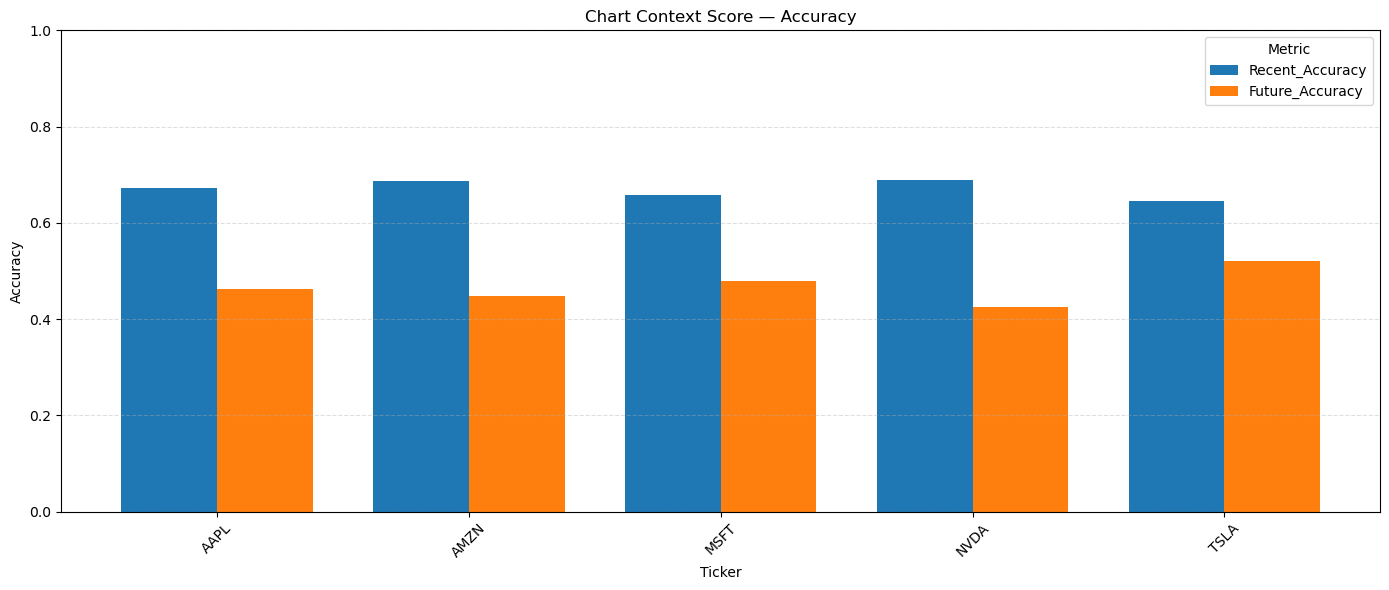

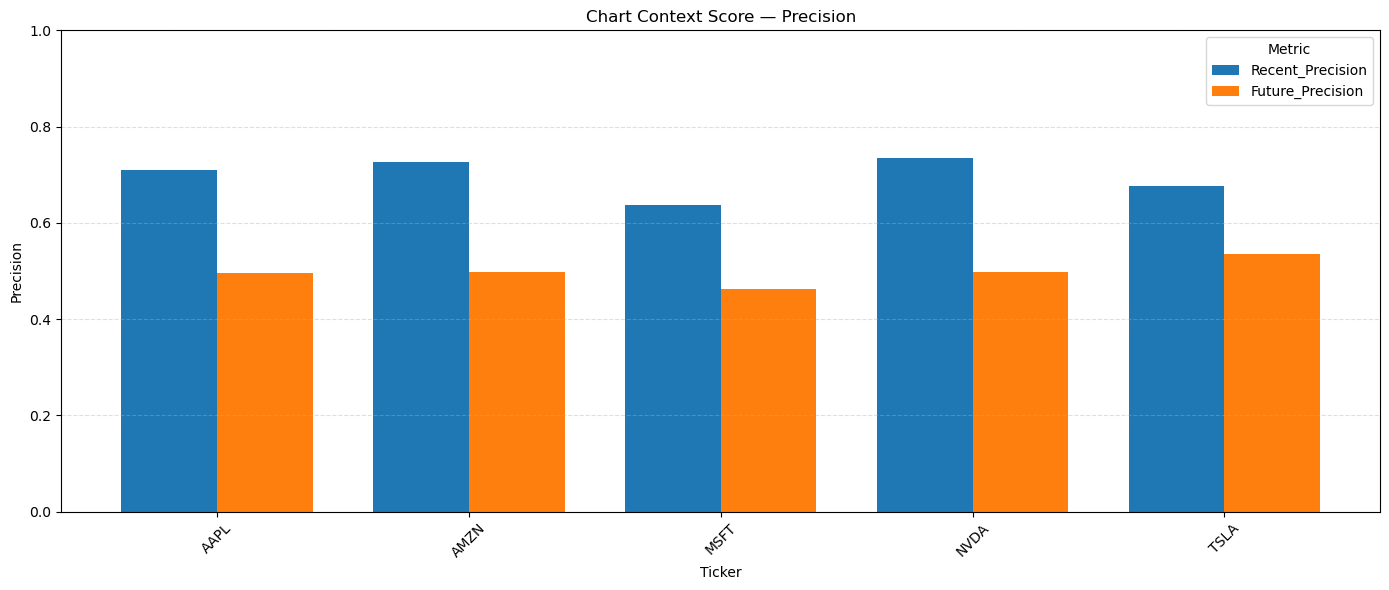

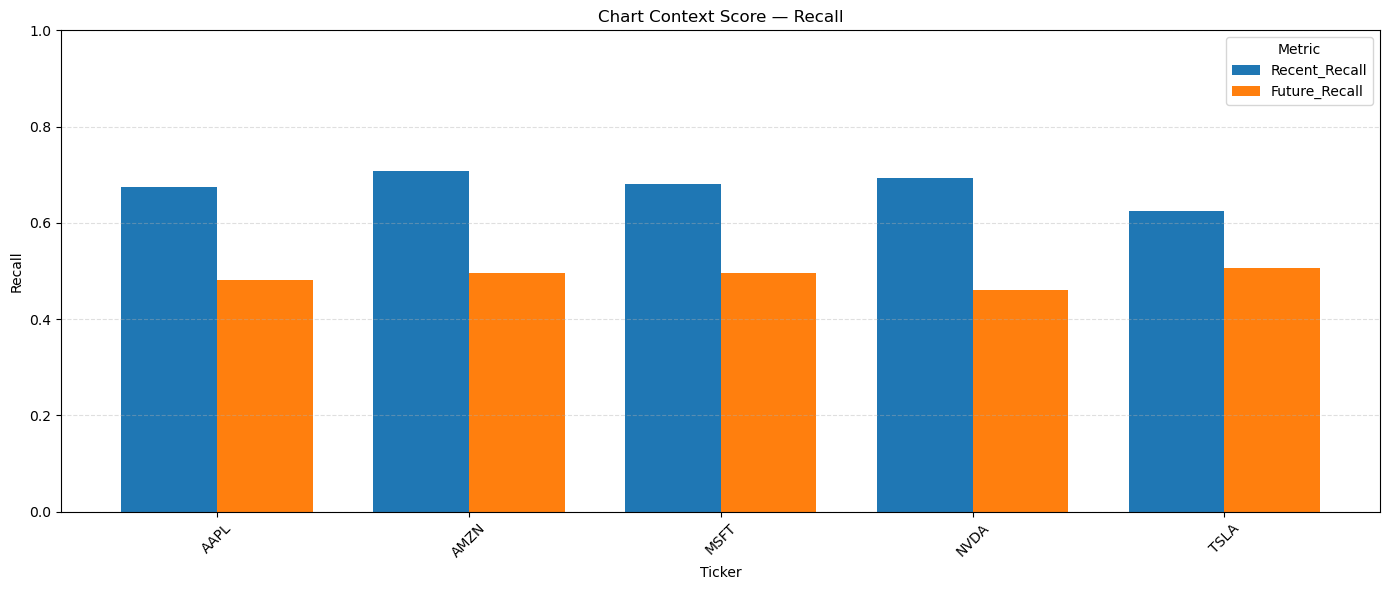

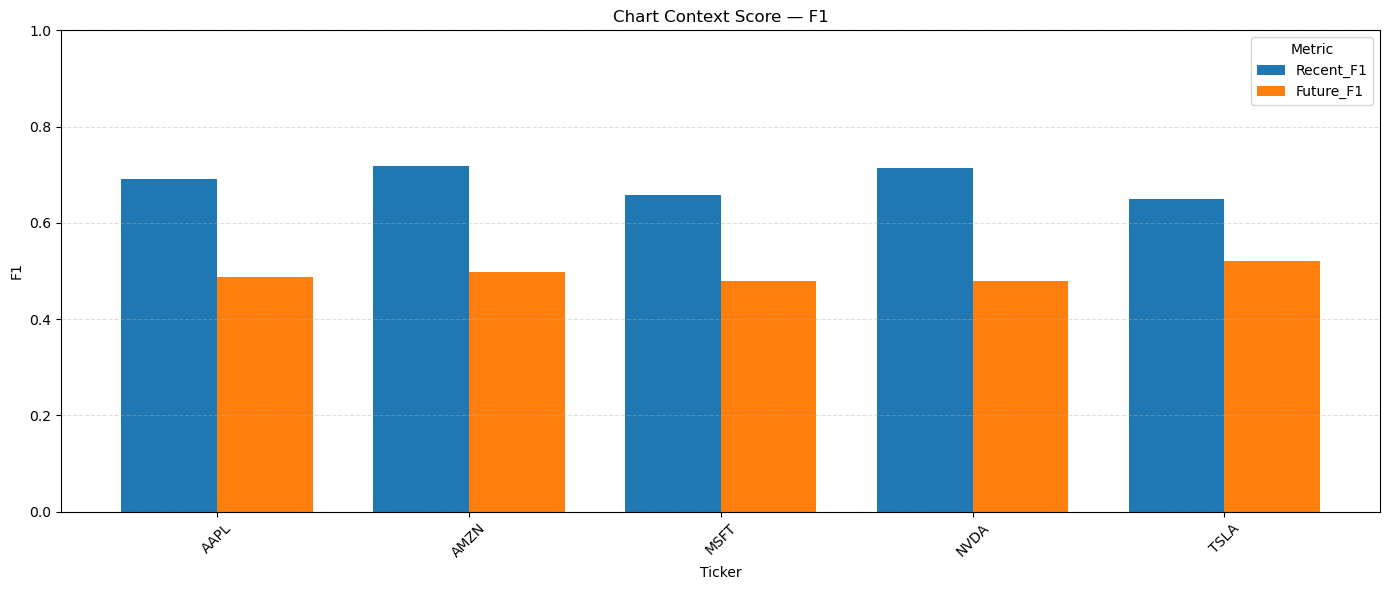

In [18]:
plot_recent_future_metric(chart_metric_df, "Accuracy")
plot_recent_future_metric(chart_metric_df, "Precision")
plot_recent_future_metric(chart_metric_df, "Recall")
plot_recent_future_metric(chart_metric_df, "F1")